In [24]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os
import scanpy as sc
import scvi
import seaborn as sns


def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols


In [2]:
21849309 + 22141865
22141865 /43991174

0.503325166998271

## Load Data

In [39]:
# Save dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')


RNA_cluster_union_cell_sufficientNfrag_subset_file = os.path.join(Union_cell_subdir, 'Union_sufficientNfrag_BCs_RNA_cluster.tsv')
union_sufficientNfrag_RNA_cluster_info = pd.read_csv(RNA_cluster_union_cell_sufficientNfrag_subset_file, sep='\t', index_col=0)

cols = ['leiden_RNA_scVI_sufficientNfrag', "leiden_RNA_scVI"]
for col in cols:
    union_sufficientNfrag_RNA_cluster_info[col] = union_sufficientNfrag_RNA_cluster_info[col].astype('category')
union_sufficientNfrag_RNA_cluster_info.head(2)

,rna_barcodes,atac_barcodes,total_RNA_UMI,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,MT%,_scvi_batch,_scvi_labels,leiden_RNA_scVI_sufficientNfrag,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
AAACAGCCAGGCTACT-1,AAACAGCCAGGCTACT,ACAGCGGGTTTGTAGC,3931.0,8.276903,1772,519.0,13.202747,0,0,1,3390,True,True,True,both,both,True,0.130478,1,NO
AAACATGCAAGGATTA-1,AAACATGCAAGGATTA,CATTTAGGTAACAGCA,3566.0,8.179481,1689,401.0,11.245092,0,0,5,11169,True,True,True,both,both,True,0.197080,3,NO


In [3]:
entropy_peaks_subdir = os.path.join(Union_cell_subdir, 'Entropy_cells_peaks')
entropy_peaks_gene_activity_file = os.path.join(entropy_peaks_subdir, 'DownstreamReanalysis', 'gene_activity_score.csv')
entropy_peaks_gene_activity = pd.read_csv(entropy_peaks_gene_activity_file, index_col=0).T

enough_frag_in_peaks_for_gene_activity = entropy_peaks_gene_activity.index.to_frame()
enough_frag_in_peaks_for_gene_activity['atac_bc'] = enough_frag_in_peaks_for_gene_activity.index.str.split('-').str[0]


In [ ]:
enough_frag_in_peaks_for_gene_activity.shape, union_sufficientNfrag_RNA_cluster_info.shape  # 1 BC does not have RNA-info

((2131, 2), (2130, 20))

# Now only subset BCs that have either enough Frag in peaks for inferring gene-activity

# Check ATAC for those union subset BCs that have sufficient frag-in-peaks for inferring gene-activity

In [6]:
entropy_peak_dir = os.path.join(Union_cell_subdir, "Entropy_cells_peaks")
atac_entropy_peak_pic = os.path.join(entropy_peak_dir, "DownstreamReanalysis", "bc_peak_pic_count.h5ad" )
h5_atac_entropy_peak = sc.read_h5ad(atac_entropy_peak_pic)
h5_atac_entropy_peak.obs['atac_barcodes'] = h5_atac_entropy_peak.obs['barcodes'].map(lambda x: x.split("-")[0])


In [30]:
h5_atac_enoughinfo = h5_atac_entropy_peak[h5_atac_entropy_peak.obs['atac_barcodes'].isin(enough_frag_in_peaks_for_gene_activity['atac_bc'])].copy()

In [31]:
h5_atac_enoughinfo

AnnData object with n_obs × n_vars = 2131 × 62565
    obs: 'barcodes', 'atac_barcodes'
    var: 'peak'

In [42]:

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

# %%
PEAKVI_LATENT_KEY = "X_peakvi_BC_sufficientNfrag"
PEAKVI_CLUSTERS_KEY = "clusters_peakvi_sufficientNfrag"

#%%
# # filter regions with less than 3% of the cells
print("# regions before filtering:", h5_atac_enoughinfo.shape[-1])

sc.pp.filter_genes(h5_atac_enoughinfo, min_cells=10)
print("# regions after filtering:", h5_atac_enoughinfo.shape[-1])

# Let's Use All the identified peaks for comarison (since entropy approach already has more peaks)
# train on h5_atac_entropy_peak_SADE
# scvi.model.PEAKVI.setup_anndata(h5_atac_enoughinfo)
# peak_model = scvi.model.PEAKVI(h5_atac_enoughinfo)
# peak_model.train()
# #save model
# des_model_dir = os.path.join(entropy_dir, "_unionBCwsufficientNfrag_PEAKVI_model")
# peak_model.save(des_model_dir, overwrite=True)

# #save latent representation back adata
des_model_dir = os.path.join(entropy_dir, "_unionBCwsufficientNfrag_PEAKVI_model")
peak_model = scvi.model.PEAKVI.load(des_model_dir, h5_atac_enoughinfo)
latent = peak_model.get_latent_representation()
h5_atac_enoughinfo.obsm[PEAKVI_LATENT_KEY] = latent
resolution = 0.5
sc.pp.neighbors(h5_atac_enoughinfo, use_rep=PEAKVI_LATENT_KEY)
sc.tl.umap(h5_atac_enoughinfo, min_dist=0.5)
sc.tl.leiden(h5_atac_enoughinfo, key_added=PEAKVI_CLUSTERS_KEY, resolution=resolution)

Seed set to 0


Last run with scvi-tools version: 1.2.0
# regions before filtering: 61526
# regions after filtering: 61526
INFO     File                                                                                                      
         /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_unionBCwsufficientNfrag_PEAKVI_model/model.pt
         already downloaded                                                                                        


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

In [64]:

col_list = [
    'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', "MT%", 
    'total_fragments', 'atac_pass_CR', 'atac_pass_entropy',
       'atac_pass_archr_TSS', '_2set_identified_by_atac_SC',
       '_2set_identified_by_atac_ST', 'rna_barcodes', 'rna_pass_CR', 'Entropy', 'DNA_debris',
       'leiden_RNA_scVI', 'leiden_RNA_scVI_sufficientNfrag']
for col in col_list:
    h5_atac_enoughinfo.obs[col] = h5_atac_enoughinfo.obs['atac_barcodes'].map(union_sufficientNfrag_RNA_cluster_info.set_index('atac_barcodes')[col])
    
h5_atac_enoughinfo.obs['log10_total_frag'] = np.log10(h5_atac_enoughinfo.obs['total_fragments'])

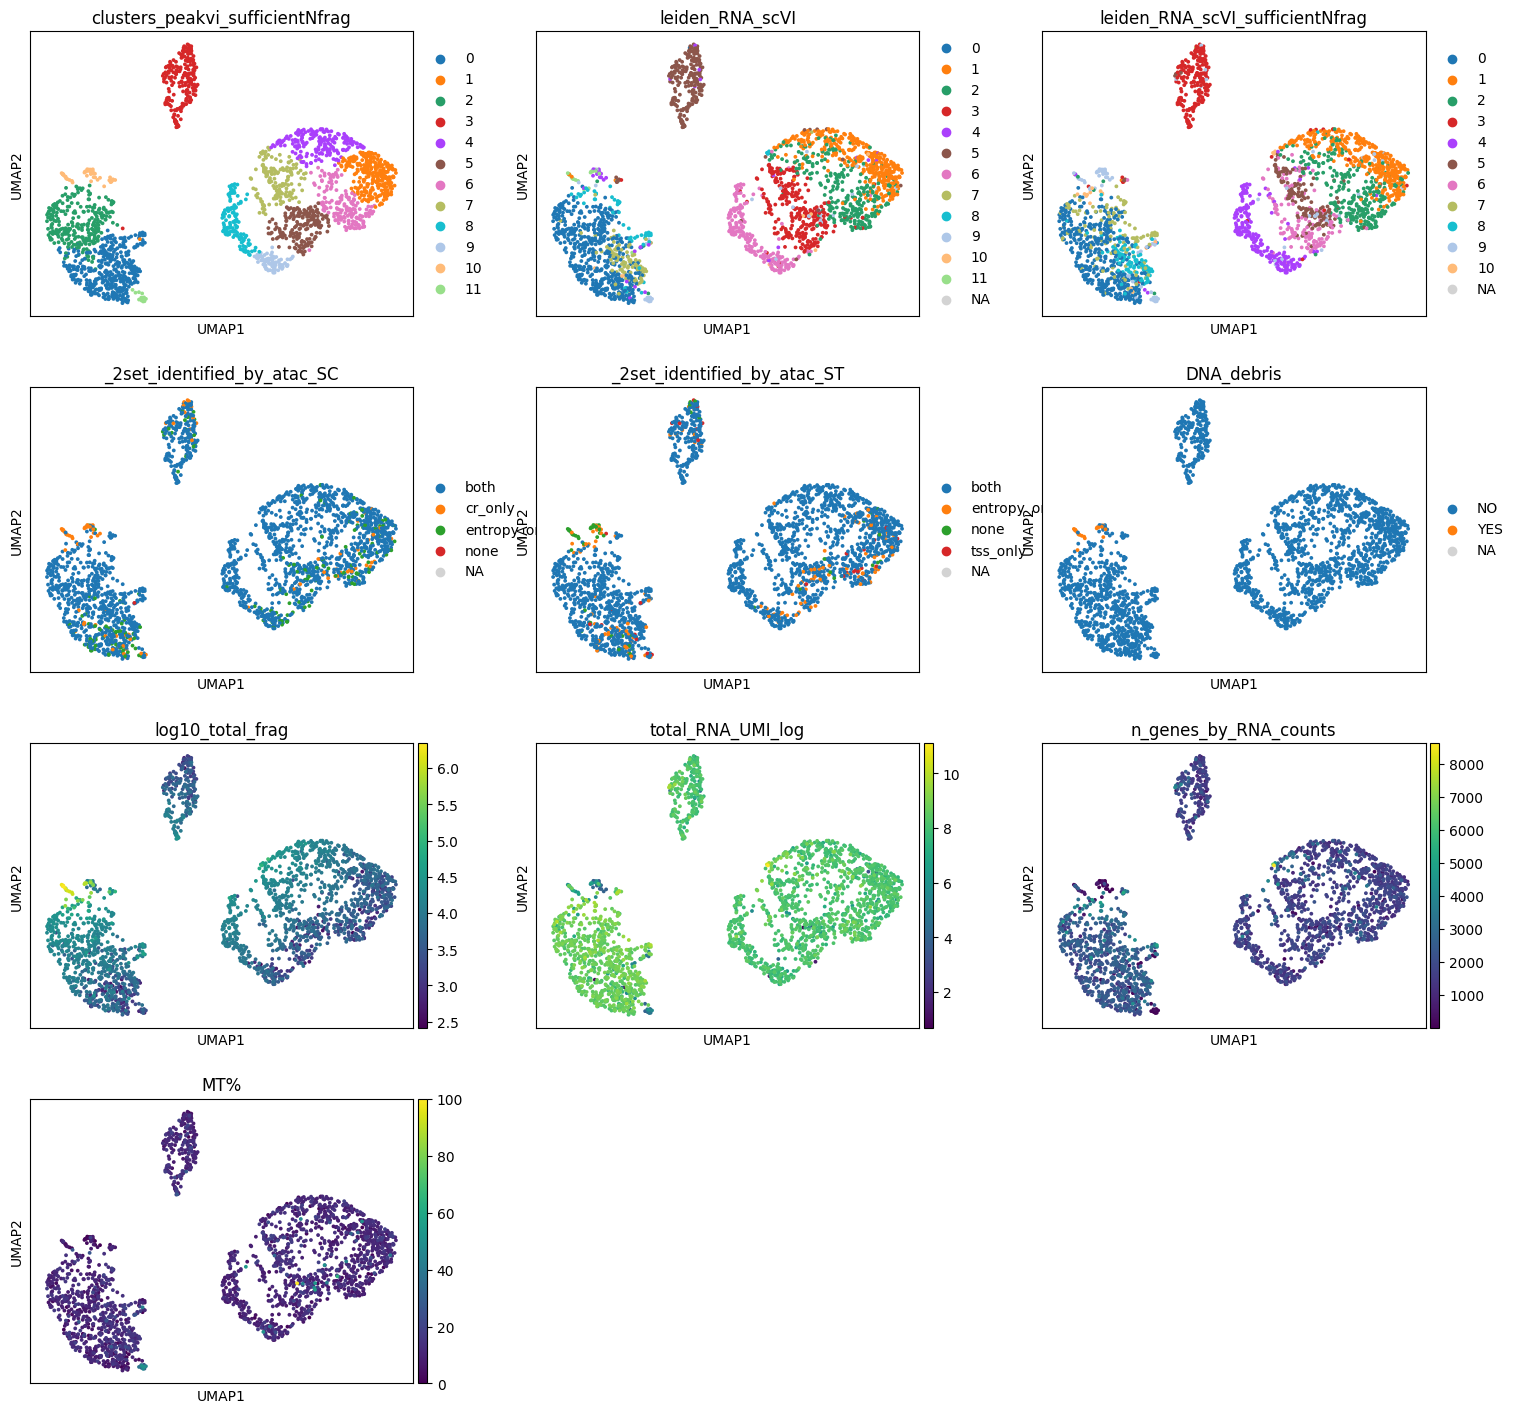

In [65]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_atac_enoughinfo, color=['clusters_peakvi_sufficientNfrag', 'leiden_RNA_scVI', 'leiden_RNA_scVI_sufficientNfrag', 
                                          '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'DNA_debris', 'log10_total_frag'] + 
               ['total_RNA_UMI_log', 'n_genes_by_RNA_counts', "MT%", ], wspace=0.2, size=30, ncols=3, )

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Text(0, 0.5, 'log10 Total Fragments')

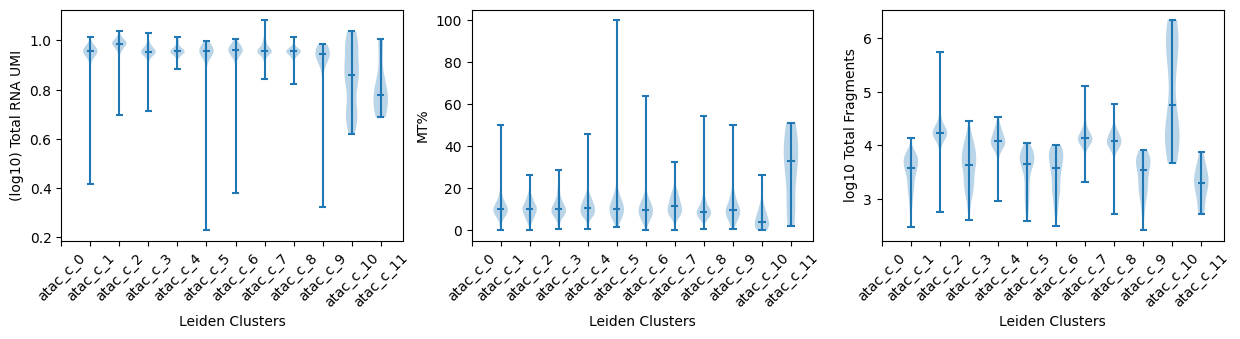

In [77]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3))

x_positions = h5_atac_enoughinfo.obs['clusters_peakvi_sufficientNfrag'].cat.codes.unique()
atac_read_depth = [h5_atac_enoughinfo.obs['total_RNA_UMI_log'].apply(lambda x: np.log10(x + 1)).loc[
    (h5_atac_enoughinfo.obs['clusters_peakvi_sufficientNfrag'].cat.codes == cluster) 
    ] for cluster in x_positions]
ax[0].violinplot(atac_read_depth, positions=x_positions, showmeans=False, showmedians=True)
ax[0].set_xticks(x_positions)
ax[0].set_xticklabels(['atac_c_' + str(i) for i in x_positions], rotation=45)
ax[0].set_xlabel('Leiden Clusters')
ax[0].set_ylabel('(log10) Total RNA UMI')


atac_mt_percent = [h5_atac_enoughinfo.obs['MT%'].loc[
    (h5_atac_enoughinfo.obs['clusters_peakvi_sufficientNfrag'].cat.codes == cluster) 
    ] for cluster in x_positions]
ax[1].violinplot(atac_mt_percent, positions=x_positions, showmeans=False, showmedians=True)
ax[1].set_xticks(x_positions)
ax[1].set_xticklabels(['atac_c_' + str(i) for i in x_positions], rotation=45)
ax[1].set_xlabel('Leiden Clusters')
ax[1].set_ylabel('MT%')


atac_total_frag = [h5_atac_enoughinfo.obs['log10_total_frag'].loc[
    (h5_atac_enoughinfo.obs['clusters_peakvi_sufficientNfrag'].cat.codes == cluster) 
    ] for cluster in x_positions]
ax[2].violinplot(atac_total_frag, positions=x_positions, showmeans=False, showmedians=True)
ax[2].set_xticks(x_positions)
ax[2].set_xticklabels(['atac_c_' + str(i) for i in x_positions], rotation=45)
ax[2].set_xlabel('Leiden Clusters')
ax[2].set_ylabel('log10 Total Fragments')

/tmp/ipykernel_807052/2599559433.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = h5_atac_enoughinfo.obs.groupby(['clusters_peakvi_sufficientNfrag', 'leiden_RNA_scVI_sufficientNfrag']).size().unstack(fill_value=0)


<Axes: xlabel='leiden_RNA_scVI_sufficientNfrag', ylabel='clusters_peakvi_sufficientNfrag'>

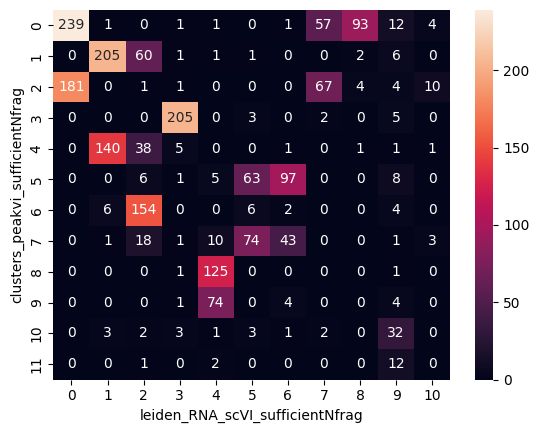

In [ ]:
g = h5_atac_enoughinfo.obs.groupby(['clusters_peakvi_sufficientNfrag', 'leiden_RNA_scVI_sufficientNfrag']).size().unstack(fill_value=0)
sns.heatmap(g, annot=True, fmt='')

In [46]:
h5_atac_enoughinfo.obs.groupby(['leiden_RNA_scVI', 'leiden_RNA_scVI_sufficientNfrag', ]).size().unstack(fill_value=0)

/tmp/ipykernel_807052/3160879896.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_atac_enoughinfo.obs.groupby(['leiden_RNA_scVI', 'leiden_RNA_scVI_sufficientNfrag', ]).size().unstack(fill_value=0)


leiden_RNA_scVI_sufficientNfrag,0,1,2,3,4,5,6,7,8,9,10
leiden_RNA_scVI,,,,,,,,,,,
0,413,1,0,2,1,0,0,91,0,0,0
1,0,329,27,0,3,1,3,0,0,0,0
2,0,23,242,0,0,17,7,0,0,0,0
3,0,0,10,0,5,124,139,0,0,0,0
4,0,0,0,0,0,1,0,0,0,34,0
5,0,0,0,218,0,6,0,0,0,0,0
6,0,0,0,0,209,0,0,0,0,0,0
7,1,0,0,0,0,0,0,0,100,0,0
8,6,0,1,0,1,0,0,37,0,0,18


/tmp/ipykernel_807052/2576619981.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relate_labels2 = h5_atac_enoughinfo.obs.groupby(['leiden_RNA_scVI', 'leiden_RNA_scVI_sufficientNfrag']).size().unstack(fill_value=0)
/tmp/ipykernel_807052/2576619981.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = h5_atac_enoughinfo.obs.groupby(['leiden_RNA_scVI', 'leiden_RNA_scVI_sufficientNfrag']).size().unstack(fill_value=0)


<Axes: xlabel='leiden_RNA_scVI_sufficientNfrag', ylabel='leiden_RNA_scVI'>

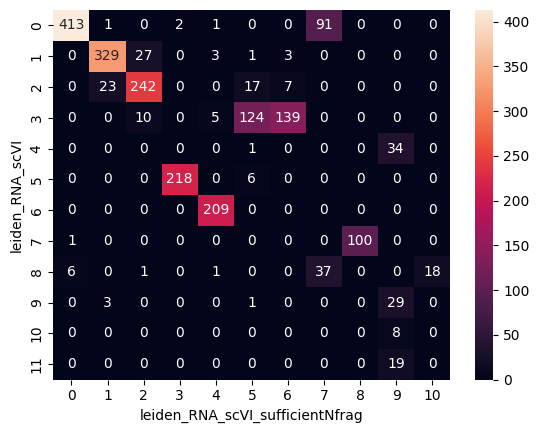

In [60]:
# Reference is 'clusters_peakvi_highres_standard'
relate_labels2 = h5_atac_enoughinfo.obs.groupby(['leiden_RNA_scVI', 'leiden_RNA_scVI_sufficientNfrag']).size().unstack(fill_value=0)
ordered_col, remained_col = order_m(relate_labels2.values)

# # Now map the best matching clusters
h5_atac_enoughinfo.obs['reorder_leiden_RNA_scVI_sufficientNfrag'] = h5_atac_enoughinfo.obs['leiden_RNA_scVI_sufficientNfrag'].cat.reorder_categories([i for i in ordered_col+remained_col], ordered=False)

g = h5_atac_enoughinfo.obs.groupby(['leiden_RNA_scVI', 'leiden_RNA_scVI_sufficientNfrag']).size().unstack(fill_value=0)

fig, ax = plt.subplots()
# Annotate integer
sns.heatmap(g, annot=True, fmt='', ) 



# DARs

In [18]:
atac_cluster_DARs = {}
cluster_list = h5_atac_enoughinfo.obs['clusters_peakvi_sufficientNfrag'].unique()
for cluster in cluster_list:
    print(f" DARs on atac-cluster {cluster}")
    atac_cluster_DARs[cluster] = peak_model.differential_accessibility(
        groupby="clusters_peakvi_sufficientNfrag", group1=cluster,  two_sided=True
    )

 DARs on atac-cluster 5
DE...: 100%|██████████| 1/1 [00:08<00:00,  8.00s/it]
 DARs on atac-cluster 0
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.12s/it]
 DARs on atac-cluster 3
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.17s/it]
 DARs on atac-cluster 2
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.30s/it]
 DARs on atac-cluster 6
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.07s/it]
 DARs on atac-cluster 7
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.19s/it]
 DARs on atac-cluster 1
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.11s/it]
 DARs on atac-cluster 4
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.20s/it]
 DARs on atac-cluster 8
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.13s/it]
 DARs on atac-cluster 9
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.14s/it]
 DARs on atac-cluster 10
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.18s/it]
 DARs on atac-cluster 11
DE...: 100%|██████████| 1/1 [00:06<00:00,  6.93s/it]


In [19]:
## manually change effect-size sign 
for cluster in atac_cluster_DARs.keys():
    atac_cluster_DARs[cluster]['effect_size_correct_sign'] = -atac_cluster_DARs[cluster]['effect_size']

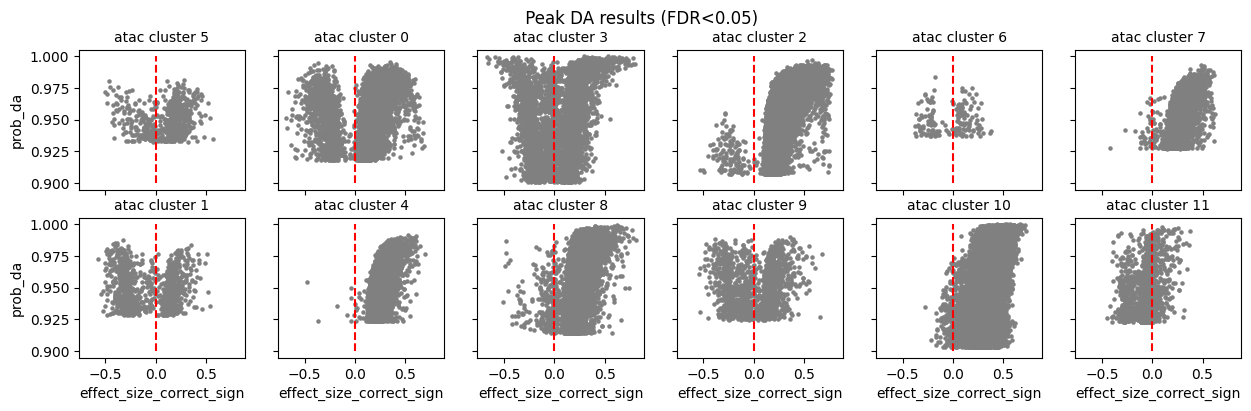

In [20]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) ].plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 5, c='grey' )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(' Peak DA results (FDR<0.05) ', fontsize=12)
plt.show()